# Particle Filter Debug Graphs
Uses collected data from a particle filter run to visualize what could be wrong.

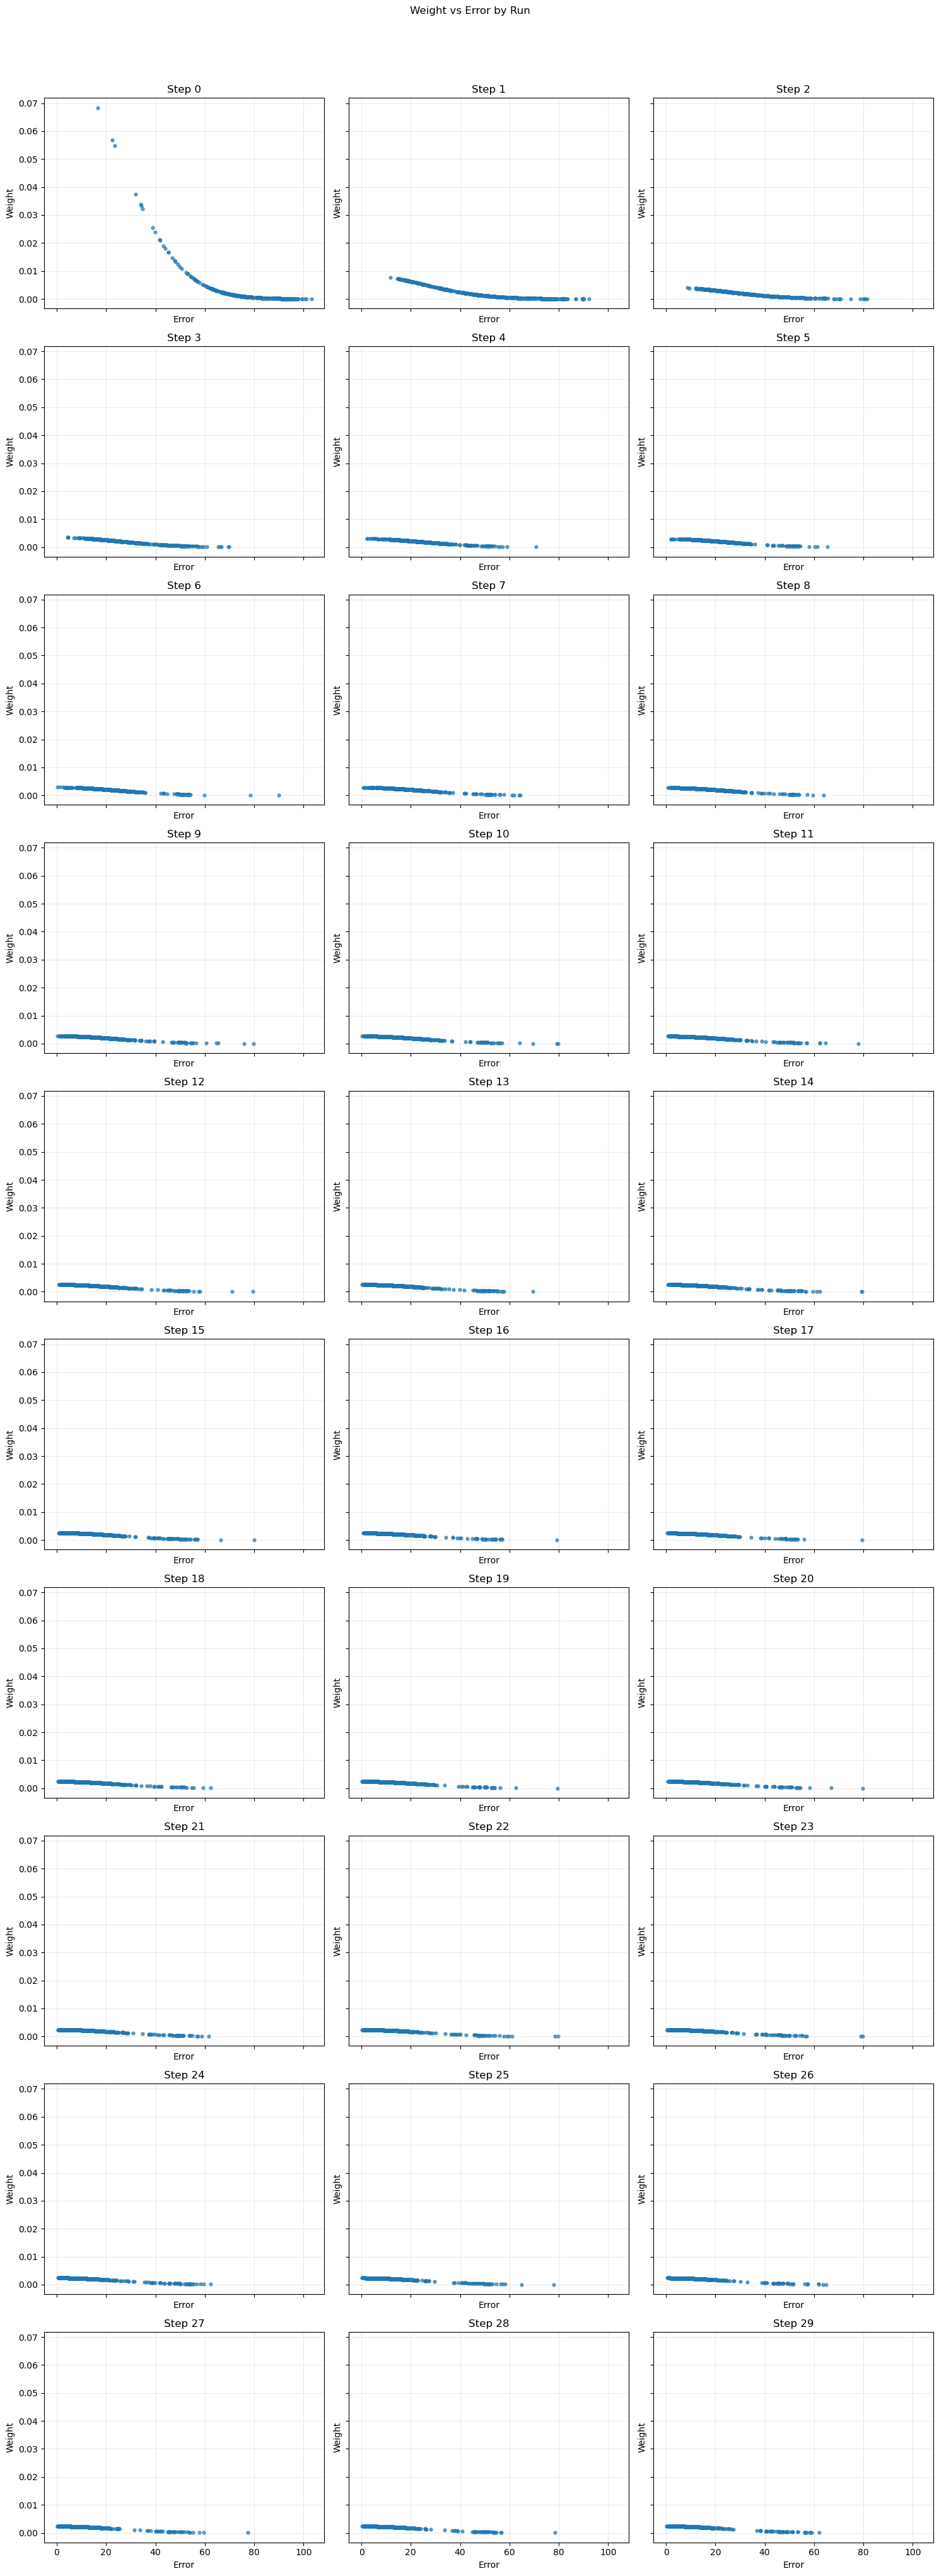

In [ ]:
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

csv_path = "particle_log_20260526_013711.csv"
df = pd.read_csv(csv_path)

if df.empty:
    print(f"No data found in {csv_path}")
else:
    steps = sorted(df["step"].unique())
    n_steps = len(steps)
    cols = 3
    rows = int(np.ceil(n_steps / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows), sharex=True, sharey=True)
    axes = axes.flatten() if n_steps > 1 else [axes]

    for ax, step in zip(axes, steps):
        step_df = df[df["step"] == step]
        ax.scatter(step_df["error"], step_df["weight"], s=12, alpha=0.7) # type: ignore
        ax.set_title(f"Step {step}") # type: ignore
        ax.set_xlabel("Error") # type: ignore
        ax.set_ylabel("Weight") # type: ignore
        ax.grid(True, alpha=0.25) # type: ignore

    for ax in axes[n_steps:]:
        ax.axis("off") # type: ignore

    fig.suptitle("Weight vs Error by Step", y=1.02)
    fig.tight_layout()
    display(fig)
    plt.close(fig)